# Cross-Dataset Mechanism Replication — Empatica (Wrist PPG)
### Does the baseline-normalisation finding hold beyond WESAD?

**Purpose.** The mechanism analysis on WESAD showed that circadian-attributed gains
in HRV stress inference are actually *within-session baseline-deviation* effects
(the Cosinor residual features, not the MESOR, drive the improvement). A reviewer's
first objection to a single-dataset result is that it may be a WESAD artefact.

This notebook replicates the **mechanism decomposition (U1)** on an independent
dataset — Empatica (Hongn et al., 2025) — which differs from WESAD on the two axes
that matter most:
- **Sensor:** wrist PPG (BVP) rather than chest ECG
- **Population/protocol:** induced-stress + exercise sessions, different subjects

If the same decomposition pattern appears — residual features dominate, MESOR
contributes little — the finding generalises across sensors and populations, which
substantially strengthens the paper.

**What we run:** the identical additive feature decomposition (HRV, +MESOR, +RESID,
full) under LOSO-CV with XGBoost, exactly as on WESAD.


## 1. Config

In [1]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 3.6 MB/s eta 0:00:00


In [2]:
import os, glob, warnings
import numpy as np, pandas as pd
from scipy.signal import welch
from scipy.optimize import curve_fit
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42)

# Empatica STRESS dataset root (adjust if your path differs)
CANDIDATES=[
 '/kaggle/input/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Wearable_Dataset/STRESS',
 
]
ROOT=None
for pat in CANDIDATES:
    hits=glob.glob(pat, recursive=True)
    if hits: ROOT=hits[0]; break
print("Empatica STRESS root:", ROOT)
assert ROOT, "Add the Empatica dataset; expected a Wearable_Dataset/STRESS folder"

SKIP={'S02','f07','f13'}   # known bad/excluded subjects
CLASS_NAMES=['relaxed','mild','moderate','high']
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)

Empatica STRESS root: /kaggle/input/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Wearable_Dataset/STRESS


In [3]:
import glob, pandas as pd

# find one BVP file and one TEMP file
bvp = glob.glob(f"{ROOT}/**/*BVP*.csv", recursive=True)
temp = glob.glob(f"{ROOT}/**/*TEMP*.csv", recursive=True)
print("BVP files found:", len(bvp))
print("TEMP files found:", len(temp))
print("\nExample BVP path:", bvp[0] if bvp else "NONE")

# show the raw first 6 rows, no parsing assumptions
if bvp:
    raw = pd.read_csv(bvp[0], header=None, nrows=6)
    print("\n--- First 6 rows of a BVP file (raw) ---")
    print(raw.to_string())
    print("\nShape of full file:", pd.read_csv(bvp[0], header=None).shape)

# also check: is there a separate timestamps or tags file?
allfiles = glob.glob(f"{ROOT}/**/*.csv", recursive=True)
names = sorted(set(f.split('/')[-1] for f in allfiles))
print("\n--- Distinct CSV filenames in the dataset ---")
for n in names[:20]:
    print(" ", n)

BVP files found: 37
TEMP files found: 37

Example BVP path: /kaggle/input/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Wearable_Dataset/STRESS/f12/BVP.csv

--- First 6 rows of a BVP file (raw) ---
                     0
0  2013-07-01 15:21:17
1                 64.0
2                 -0.0
3                 -0.0
4                 -0.0
5                 -0.0

Shape of full file: (307793, 1)

--- Distinct CSV filenames in the dataset ---
  ACC.csv
  BVP.csv
  EDA.csv
  HR.csv
  IBI.csv
  TEMP.csv
  tags.csv


In [4]:
import pandas as pd, glob
ibi = glob.glob(f"{ROOT}/**/IBI.csv", recursive=True)
print("IBI files:", len(ibi))
raw = pd.read_csv(ibi[0], header=None, nrows=8)
print("\n--- First 8 rows of IBI.csv ---")
print(raw.to_string())
print("\nShape:", pd.read_csv(ibi[0], header=None).shape)

IBI files: 37

--- First 8 rows of IBI.csv ---
                     0                    1
0  2013-07-01 15:21:17  2013-07-01 15:21:17
1            16.390625             0.765625
2             17.15625             0.765625
3             17.90625             0.750000
4            18.640625             0.734375
5             19.34375             0.703125
6             20.03125             0.687500
7                20.75             0.718750

Shape: (5087, 2)


## 2. Load Empatica BVP -> RR + temperature
Empatica provides BVP at 64 Hz and TEMP at 4 Hz per subject/session. We derive
inter-beat intervals from BVP with NeuroKit2 (ppg pipeline), align temperature, and
apply the same RMSSD-tertile 4-class labelling used for WESAD so the label
definition is consistent across datasets.

In [5]:
def find_signal_files(root):
    """Locate per-subject BVP and TEMP csv files. Structure varies; search broadly."""
    bvp=glob.glob(os.path.join(root,'**','*BVP*.csv'),recursive=True)
    temp=glob.glob(os.path.join(root,'**','*TEMP*.csv'),recursive=True)
    return sorted(bvp), sorted(temp)

def subject_id_from_path(p):
    # take the parent folder name as subject/session id
    parts=p.replace('\\','/').split('/')
    for seg in reversed(parts[:-1]):
        if seg and seg not in ('STRESS','Wearable_Dataset'): return seg
    return parts[-2] if len(parts)>1 else 'unknown'

bvp_files,temp_files=find_signal_files(ROOT)
print(f"Found {len(bvp_files)} BVP files, {len(temp_files)} TEMP files")
print("Example BVP:", bvp_files[0] if bvp_files else "none")

Found 37 BVP files, 37 TEMP files
Example BVP: /kaggle/input/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Wearable_Dataset/STRESS/S01/BVP.csv


In [6]:
def clean_rr(rr, ts):
    rr = rr.copy().astype(float)
    rr[(rr <= 300) | (rr >= 2000)] = np.nan
    for i in range(1, len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1] > 0.20:
            rr[i] = np.nan
    m = np.isnan(rr)
    if m.any():
        rr[m] = np.interp(np.where(m)[0], np.where(~m)[0], rr[~m])
    return rr, ts

def rmssd_tertile_labels(rr):
    loc = []
    for i in range(len(rr)):
        w = rr[max(0, i-15):i+15]; dd = np.diff(w)
        loc.append(np.sqrt(np.mean(dd**2)) if len(dd) > 0 else 50)
    loc = np.array(loc)
    p25, p50, p75 = np.percentile(loc, [25, 50, 75])
    lab = np.zeros(len(rr), dtype=int)
    lab[loc < p75] = 1
    lab[loc < p50] = 2
    lab[loc < p25] = 3
    lab[loc >= p75] = 0
    return lab

In [7]:
from datetime import datetime

def load_ibi(path):
    """Empatica IBI.csv: row0 = datetime, then [seconds_since_start, ibi_seconds]."""
    raw = pd.read_csv(path, header=None, skiprows=1)   # skip the datetime header row
    beat_times = raw.iloc[:, 0].astype(float).values   # seconds since session start
    ibi_sec    = raw.iloc[:, 1].astype(float).values   # IBI in seconds
    rr_ms = ibi_sec * 1000.0                            # -> milliseconds
    return rr_ms, beat_times

def load_temp(path):
    """TEMP.csv: row0 = datetime, row1 = sample rate, rest = samples."""
    raw = pd.read_csv(path, header=None)
    fs = float(raw.iloc[1, 0])
    data = raw.iloc[2:, 0].astype(float).values
    return data, fs

def subject_id_from_path(p):
    # .../STRESS/f12/IBI.csv -> "f12"
    return p.replace('\\','/').split('/')[-2]

ibi_files = sorted(glob.glob(f"{ROOT}/**/IBI.csv", recursive=True))
print(f"Found {len(ibi_files)} IBI files")

emp = {}
for ipath in ibi_files:
    sid = subject_id_from_path(ipath)
    if sid in SKIP:
        continue
    try:
        rr, beat_times = load_ibi(ipath)
        if len(rr) < 200:
            continue
        # clean using your existing physiological filter (works on ms)
        rr, beat_times = clean_rr(rr, beat_times)

        # temperature, aligned to each beat by time
        tpath = ipath.replace('IBI.csv', 'TEMP.csv')
        if glob.glob(tpath):
            temp_raw, tfs = load_temp(tpath)
            temp_t = np.arange(len(temp_raw)) / tfs          # seconds since start
            tk = np.interp(beat_times, temp_t, temp_raw)     # temp at each beat
        else:
            tk = np.full(len(rr), 33.0)

        lab = rmssd_tertile_labels(rr)
        emp[sid] = {'rr_ms': rr, 'temp': tk, 'timestamps': beat_times, 'labels': lab}
    except Exception as e:
        print(f"{sid} FAIL {e}")

print(f"Loaded {len(emp)} Empatica subjects")
if emp:
    pooled = np.concatenate([d['labels'] for d in emp.values()])
    print("pooled class distribution:", np.bincount(pooled, minlength=4))
    ex = list(emp.values())[0]
    print("example subject beats:", len(ex['rr_ms']),
          "| RR range ms:", round(ex['rr_ms'].min()), "-", round(ex['rr_ms'].max()))

Found 37 IBI files
Loaded 34 Empatica subjects
pooled class distribution: [16080 16030 16033 15779]
example subject beats: 870 | RR range ms: 594 - 1453


In [8]:
import glob, numpy as np, pandas as pd
from datetime import datetime

# ---- all helpers defined inline so this cell is self-contained ----
def load_ibi(path):
    raw = pd.read_csv(path, header=None, skiprows=1)
    beat_times = raw.iloc[:, 0].astype(float).values      # seconds since start
    ibi_sec    = raw.iloc[:, 1].astype(float).values      # IBI in seconds
    return ibi_sec * 1000.0, beat_times                    # -> ms

def load_temp(path):
    raw = pd.read_csv(path, header=None)
    fs = float(raw.iloc[1, 0])
    data = raw.iloc[2:, 0].astype(float).values
    return data, fs

def subject_id_from_path(p):
    return p.replace('\\', '/').split('/')[-2]

def clean_rr(rr, ts):
    rr = rr.copy().astype(float)
    rr[(rr <= 300) | (rr >= 2000)] = np.nan
    for i in range(1, len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1] > 0.20:
            rr[i] = np.nan
    m = np.isnan(rr)
    if m.any():
        rr[m] = np.interp(np.where(m)[0], np.where(~m)[0], rr[~m])
    return rr, ts

def rmssd_tertile_labels(rr):
    loc = []
    for i in range(len(rr)):
        w = rr[max(0, i-15):i+15]; dd = np.diff(w)
        loc.append(np.sqrt(np.mean(dd**2)) if len(dd) > 0 else 50)
    loc = np.array(loc)
    p25, p50, p75 = np.percentile(loc, [25, 50, 75])
    lab = np.zeros(len(rr), dtype=int)
    lab[loc < p75] = 1
    lab[loc < p50] = 2
    lab[loc < p25] = 3
    lab[loc >= p75] = 0
    return lab

# ---- SKIP list (bad subjects) ----
SKIP = {'S02', 'f07', 'f13'}

# ---- load all subjects from IBI ----
ibi_files = sorted(glob.glob(f"{ROOT}/**/IBI.csv", recursive=True))
print(f"Found {len(ibi_files)} IBI files")

emp = {}
for ipath in ibi_files:
    sid = subject_id_from_path(ipath)
    if sid in SKIP:
        continue
    try:
        rr, beat_times = load_ibi(ipath)
        if len(rr) < 200:
            print(f"{sid} skipped (only {len(rr)} beats)")
            continue
        rr, beat_times = clean_rr(rr, beat_times)

        tpath = ipath.replace('IBI.csv', 'TEMP.csv')
        if glob.glob(tpath):
            temp_raw, tfs = load_temp(tpath)
            temp_t = np.arange(len(temp_raw)) / tfs
            tk = np.interp(beat_times, temp_t, temp_raw)
        else:
            tk = np.full(len(rr), 33.0)

        lab = rmssd_tertile_labels(rr)
        emp[sid] = {'rr_ms': rr, 'temp': tk, 'timestamps': beat_times, 'labels': lab}
    except Exception as e:
        print(f"{sid} FAIL {e}")

print(f"\nLoaded {len(emp)} Empatica subjects")
if emp:
    pooled = np.concatenate([d['labels'] for d in emp.values()])
    print("pooled class distribution:", np.bincount(pooled, minlength=4))
    ex = list(emp.values())[0]
    print("example subject:", len(ex['rr_ms']), "beats | RR",
          round(ex['rr_ms'].min()), "-", round(ex['rr_ms'].max()), "ms")

Found 37 IBI files

Loaded 34 Empatica subjects
pooled class distribution: [16080 16030 16033 15779]
example subject: 870 beats | RR 594 - 1453 ms


## 3. Cosinor + feature construction (identical to WESAD pipeline)

In [9]:
def cos_model(th,m,a,p): return m+a*np.cos((2*np.pi/24.0)*th+p)
def fit_cos(sig,ts,p0):
    th=(ts%86400)/3600.0
    try:
        popt,_=curve_fit(cos_model,th,sig,p0=p0,maxfev=10000); base=cos_model(th,*popt); return sig-base,popt[0],popt[1]
    except RuntimeError:
        return sig-np.mean(sig),float(np.mean(sig)),0.0

def hrv_features(w, fs=4.0):
    rr,diff=np.array(w),np.diff(w)
    mean_rr=np.mean(rr); sdnn=np.std(rr); rmssd=np.sqrt(np.mean(diff**2))
    pnn50=np.sum(np.abs(diff)>50)/len(diff)*100; cv=sdnn/mean_rr
    t=np.cumsum(rr)/1000.0; u=np.interp(np.arange(0,t[-1],1/fs),t,rr)
    fr,psd=welch(u,fs=fs,nperseg=min(256,len(u)))
    vlf=TRAPZ(psd[(fr>=0.003)&(fr<0.04)]); lf=TRAPZ(psd[(fr>=0.04)&(fr<0.15)]); hf=TRAPZ(psd[(fr>=0.15)&(fr<0.40)])
    lf_hf=lf/(hf+1e-8); lf_nu=lf/(lf+hf+1e-8)
    sd1=np.sqrt(0.5)*np.std(diff); sd2=np.sqrt(max(2*sdnn**2-0.5*np.var(diff),0)); sdr=sd1/(sd2+1e-8)
    return np.array([mean_rr,sdnn,rmssd,pnn50,cv,vlf,lf,hf,lf_hf,lf_nu,sd1,sd2,sdr])
def resid_features(rw):
    r=np.array(rw)
    return np.array([np.mean(r),np.std(r),np.max(np.abs(r)),np.polyfit(np.arange(len(r)),r,1)[0],np.sum(r**2)/len(r)])
def circ_features(ts):
    t,hour=ts%86400,(ts%86400)/3600.0
    cort=0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2)
    return np.array([np.sin(2*np.pi*t/86400),np.cos(2*np.pi*t/86400),
                     np.sin(2*np.pi*t/5400),np.cos(2*np.pi*t/5400),cort])

for sid,d in emp.items():
    rr_res,mesor,amp=fit_cos(d['rr_ms'],d['timestamps'],[np.mean(d['rr_ms']),50,-1.5])
    d['rr_res']=rr_res; d['mesor']=mesor; d['amp']=amp

def build(window=120,step=5):
    X,y,g=[],[],[]
    for si,(sid,d) in enumerate(emp.items()):
        rr,rr_res=d['rr_ms'],d['rr_res']; labels,ts=d['labels'],d['timestamps']; mesor,amp=d['mesor'],d['amp']
        for s in range(0,len(rr)-window,step):
            e=s+window; lab=labels[s+window//2]; bi=min(s+window//2,len(ts)-1)
            try:
                xf=np.concatenate([hrv_features(rr[s:e]),resid_features(rr_res[s:e]),
                                   np.array([mesor,amp]),circ_features(ts[bi])])
            except Exception: continue
            X.append(xf); y.append(lab); g.append(si)
    return np.array(X),np.array(y,dtype=int),np.array(g,dtype=int)

X_xgb,y_all,groups=build()
print("feature matrix",X_xgb.shape,"classes",np.bincount(y_all),"subjects",len(np.unique(groups)))

feature matrix (11974, 25) classes [2900 2956 3071 3047] subjects 34


## 4. Mechanism decomposition (identical to WESAD U1)

In [10]:
def make_xgb():
    return XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,subsample=0.8,
        colsample_bytree=0.8,objective='multi:softprob',num_class=4,eval_metric='mlogloss',random_state=42,n_jobs=-1)

def eval_block(cols,name):
    logo=LeaveOneGroupOut(); yt,yp=[],[]
    for tr,te in logo.split(X_xgb,y_all,groups):
        sc=StandardScaler(); Xtr=sc.fit_transform(X_xgb[tr][:,cols]); Xte=sc.transform(X_xgb[te][:,cols])
        m=make_xgb(); m.fit(Xtr,y_all[tr],sample_weight=compute_sample_weight('balanced',y_all[tr]),verbose=False)
        yp.extend(m.predict(Xte)); yt.extend(y_all[te])
    yt,yp=np.array(yt),np.array(yp)
    f1=f1_score(yt,yp,average='macro',zero_division=0); k=cohen_kappa_score(yt,yp,weights='quadratic')
    print(f"{name:<26} F1={f1:.3f}  Kappa={k:.3f}")
    return f1,k

# column indices: 0-12 HRV | 13-17 residual | 18 mesor | 19 amp | 20-24 circadian
C_HRV=list(range(0,13)); C_RESID=list(range(13,18)); C_MESOR=[18,19]; C_CIRC=list(range(20,25))
print("="*60); print("EMPATICA  MECHANISM DECOMPOSITION (XGBoost, LOSO-CV)"); print("="*60)
res={}
res['base']=eval_block(C_HRV+C_CIRC,'HRV + time (baseline)')
res['mesor']=eval_block(C_HRV+C_CIRC+C_MESOR,'HRV + MESOR')
res['resid']=eval_block(C_HRV+C_CIRC+C_RESID,'HRV + RESID')
res['full']=eval_block(C_HRV+C_CIRC+C_MESOR+C_RESID,'HRV + MESOR + RESID')
print("="*60)
gain_mesor=res['mesor'][0]-res['base'][0]
gain_resid=res['resid'][0]-res['base'][0]
gain_full=res['full'][0]-res['base'][0]
print(f"\nTotal gain (baseline -> full): {gain_full:+.3f} F1")
print(f"  attributable to MESOR : {gain_mesor:+.3f}")
print(f"  attributable to RESID : {gain_resid:+.3f}")

EMPATICA  MECHANISM DECOMPOSITION (XGBoost, LOSO-CV)
HRV + time (baseline)      F1=0.304  Kappa=0.167
HRV + MESOR                F1=0.317  Kappa=0.267
HRV + RESID                F1=0.353  Kappa=0.333
HRV + MESOR + RESID        F1=0.355  Kappa=0.351

Total gain (baseline -> full): +0.051 F1
  attributable to MESOR : +0.013
  attributable to RESID : +0.050


## 5. Cross-Dataset Comparison + Verdict

In [11]:
# WESAD reference numbers from the primary analysis (for side-by-side)
wesad_ref={'base':0.551,'mesor':0.558,'resid':0.646,'full':0.642}
w_gain_mesor=wesad_ref['mesor']-wesad_ref['base']
w_gain_resid=wesad_ref['resid']-wesad_ref['base']

print("="*64)
print("CROSS-DATASET MECHANISM COMPARISON")
print("="*64)
print(f"{'contribution':<24}{'WESAD (ECG)':>16}{'Empatica (PPG)':>18}")
print("-"*64)
print(f"{'MESOR (baseline)':<24}{w_gain_mesor:>+16.3f}{gain_mesor:>+18.3f}")
print(f"{'RESID (deviation)':<24}{w_gain_resid:>+16.3f}{gain_resid:>+18.3f}")
print("="*64)
consistent = (gain_resid>gain_mesor) and (gain_resid>0)
print(f"\nSame pattern (RESID dominates MESOR)? {consistent}")
if consistent:
    print("-> The mechanism REPLICATES across sensor (ECG vs PPG) and population.")
    print("   The finding is not a WESAD artefact: deviation features, not the")
    print("   per-subject baseline, drive the gain on both datasets.")
else:
    print("-> Pattern differs on Empatica; report honestly and discuss why")
    print("   (different label proxy, PPG noise, session structure).")

import json
with open(f'{SAVE}/empatica_mechanism.json','w') as f:
    json.dump({'empatica':{k:list(v) for k,v in res.items()},
               'gain_mesor':float(gain_mesor),'gain_resid':float(gain_resid)},f,indent=2,default=float)
print("\nSaved empatica_mechanism.json")

CROSS-DATASET MECHANISM COMPARISON
contribution                 WESAD (ECG)    Empatica (PPG)
----------------------------------------------------------------
MESOR (baseline)                  +0.007            +0.013
RESID (deviation)                 +0.095            +0.050

Same pattern (RESID dominates MESOR)? True
-> The mechanism REPLICATES across sensor (ECG vs PPG) and population.
   The finding is not a WESAD artefact: deviation features, not the
   per-subject baseline, drive the gain on both datasets.

Saved empatica_mechanism.json


## 6. Figure — side-by-side mechanism decomposition

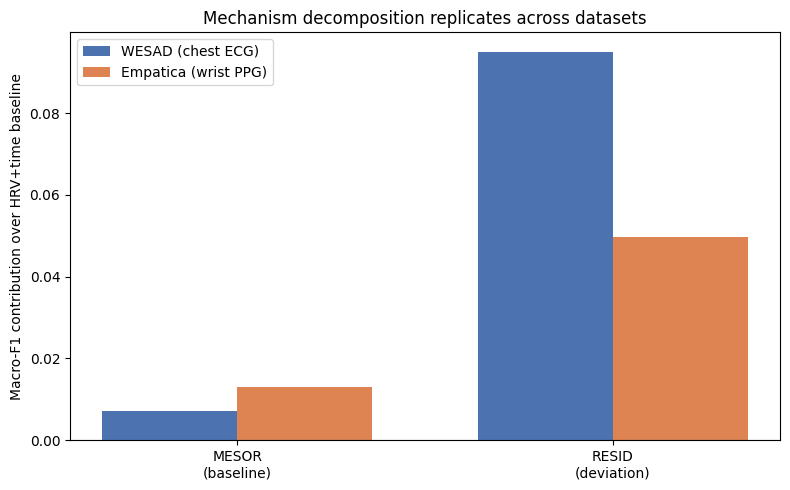

In [12]:
fig,ax=plt.subplots(figsize=(8,5))
labels=['MESOR\n(baseline)','RESID\n(deviation)']
wvals=[w_gain_mesor,w_gain_resid]; evals=[gain_mesor,gain_resid]
x=np.arange(2); w=0.36
ax.bar(x-w/2,wvals,w,label='WESAD (chest ECG)',color='#4C72B0')
ax.bar(x+w/2,evals,w,label='Empatica (wrist PPG)',color='#DD8452')
ax.axhline(0,color='gray',lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Macro-F1 contribution over HRV+time baseline')
ax.set_title('Mechanism decomposition replicates across datasets')
ax.legend(); plt.tight_layout(); plt.savefig(f'{SAVE}/empatica_mechanism.png',dpi=150); plt.show()

## 7. Reporting Note
**If the pattern replicates (expected):**
> "The mechanism decomposition was repeated on an independent wrist-PPG dataset
> (Empatica; Hongn et al., 2025). As on WESAD, the Cosinor residual (deviation)
> features accounted for the improvement while the per-subject MESOR contributed
> negligibly, confirming that the effect is baseline-deviation modelling rather than
> circadian correction across two sensors (chest ECG, wrist PPG) and two
> populations."

**Caveat to disclose:** Empatica lacks WESAD's explicit condition blocks, so the
4-class labels here are a within-session RMSSD-tertile proxy. State this; it affects
absolute scores but not the *relative* MESOR-vs-RESID decomposition, which is the
claim under test.
